In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from __loader__ import LINCSpaths, CCLEpaths, Loader
from __analysis__ import annotate_drug_info, annotate_cell_info

/home/gdelrot/pathway_perturb/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
INPUT    = Path('/home/gdelrot/pathway_perturb/data')
OUTPUT   = Path('/home/gdelrot/pathway_perturb/outputs/out_exploration_2')
MNT_L1000 = Path('/mnt/cbib/l1000/data/')
lincs_sigcom = LINCSpaths(
        gctx=str(MNT_L1000 / 'cp_coeff_mat.gctx'),
        pathway=str(INPUT / 'gsea_l1000.parquet'),
        sig_info=str(MNT_L1000 / 'siginfo_beta.txt'),
        gene_info=str(MNT_L1000 / 'geneinfo_beta.txt.gz'),
        cell_info=str(MNT_L1000 / 'cellinfo_beta.txt.gz'),
        compound_info=str(MNT_L1000 / 'compoundinfo_beta.txt.gz'),
        inst_info=str(MNT_L1000 / 'instinfo_beta.txt.gz'),
    )
ccle_data = CCLEpaths(
    transcriptomics=str(INPUT / 'CCLE_RNAseq_genes_rpkm_20180929.gct'),
    metabolomics=str(INPUT / 'CCLE_metabolomics_20190502.csv'),
    cell_annotations=str(INPUT / 'Cell_lines_annotations_20181226.txt'),
    metabo_mapping=str(INPUT / 'metabo_mapping.csv'),
    depmap_annotation=str(INPUT / 'Depmap_annotation.csv'),
)
loader = Loader(lincs_paths=lincs_sigcom, ccle_paths=ccle_data)
loader.load_l1000_metadata()
loader.load_l1000_pathway_scores()

Loading metadata nested in gctx file...


chd                                  cell_line  inchi_key  lincs_id  \
cid                                                                   
ABY001_A375_XH:BRD-K66175015:10:24         NaN        NaN       NaN   
ABY001_A375_XH:BRD-K70401845:10:24         NaN        NaN       NaN   
ABY001_A375_XH:BRD-K85606544:10:24         NaN        NaN       NaN   
ABY001_A375_XH:BRD-K19687926:10:24         NaN        NaN       NaN   
ABY001_A375_XH:BRD-K66175015:2.5:24        NaN        NaN       NaN   

chd                                  pert_aliases  pert_dose  pert_id  \
cid                                                                     
ABY001_A375_XH:BRD-K66175015:10:24            NaN        NaN      NaN   
ABY001_A375_XH:BRD-K70401845:10:24            NaN        NaN      NaN   
ABY001_A375_XH:BRD-K85606544:10:24            NaN        NaN      NaN   
ABY001_A375_XH:BRD-K19687926:10:24            NaN        NaN      NaN   
ABY001_A375_XH:BRD-K66175015:2.5:24           NaN        NaN    

In [4]:
# Statistics onto compounds
compound_info = loader.compound_info.copy()

print('Number of drugs in the l1000 metadata: \n',
      compound_info['cmap_name'].nunique())

compound_info = compound_info.dropna(subset=['moa'])
print('Unique compounds with available moa : ',
      compound_info['cmap_name'].nunique())
print('N different MOAs : \n',
      compound_info['moa'].nunique())

nas_moas = compound_info['moa'].isna().sum()
print("Fraction of drug with MOA: ",
      (1- nas_moas/compound_info.shape[0]))
count_moa = compound_info.groupby('moa').count()['cmap_name']
print(count_moa.mean())

compound_info = loader.compound_info.copy()
compound_info = compound_info.dropna(subset=['cluster_id'])

print('N different smiles clusters : \n',
      compound_info['cluster_id'].nunique())
na_smiles = compound_info['cluster_id'].isna().sum()
print("Fraction of drug with smiles cluster: ",
      (1- na_smiles/compound_info.shape[0]))

count_smiles = compound_info.groupby('cluster_id').count()['cmap_name']
print(count_smiles.mean())

Number of drugs in the l1000 metadata: 
 27843
Unique compounds with available moa :  2555
N different MOAs : 
 657
Fraction of drug with MOA:  1.0
142.4337899543379
N different smiles clusters : 
 3472
Fraction of drug with smiles cluster:  1.0
34.31077188940092



 len(common_samples)=385773 perturbations with known moa
moa
Proteasome inhibitor                       17592
EGFR inhibitor                              9264
HDAC inhibitor                              8905
MTOR inhibitor                              8514
Dopamine receptor antagonist                8267
                                           ...  
Antifibrinolytic                               3
Succinimide antiepileptic                      3
Sigma receptor ligand                          1
Dopamine receptor ligand                       1
Trace amine associated receptor agonist        1
Name: count, Length: 581, dtype: int64

 len(common_samples)=685579 perturbations with known cluster_id
cluster_id
2663.0    21501
2090.0     8708
2091.0     8463
2666.0     6999
2695.0     6676
          ...  
1472.0        1
3312.0        1
3096.0        1
1111.0        1
2453.0        1
Name: count, Length: 3472, dtype: int64


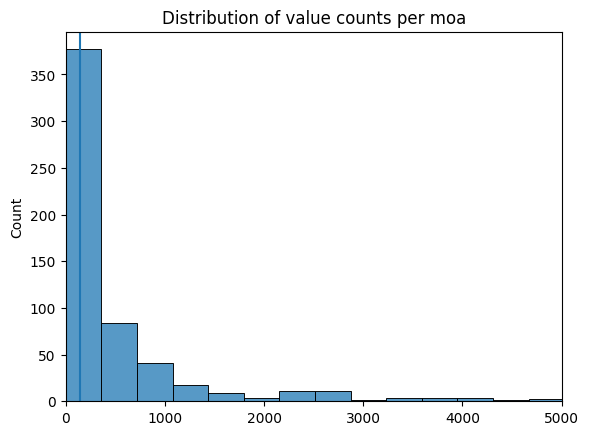

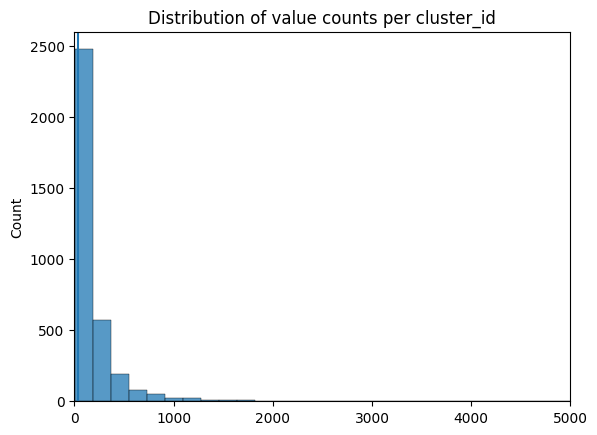

In [5]:
# Check the N pertubrations datapoints/ metadata
sig_list = set(loader.l1000_pathway_data.index)

for drug in ['moa','cluster_id']:
    chemical_table = loader.compound_info.copy()
    sig_info = loader.sig_info.loc[:,['pert_id','sig_id']]

    chemical_table = chemical_table.drop(columns=['target']).drop_duplicates(subset='pert_id').copy()
    drug_metadata = pd.merge(sig_info, chemical_table, on='pert_id',how = 'left')
    drug_metadata = drug_metadata.dropna(subset=drug)
    drug_metadata = drug_metadata.set_index('sig_id')[drug]

    pert_drugs = set(drug_metadata.index)

    common_samples = sig_list.intersection(pert_drugs)
    print(f'\n {len(common_samples)=} perturbations with known {drug}')
    print(drug_metadata.value_counts())
    value_dist = drug_metadata.value_counts().sort_values(ascending=False).values
    
    ax,fig = plt.subplots(1,1)
    sns.histplot(data=value_dist)
    plt.title(f'Distribution of value counts per {drug}')
    plt.xlim(0,5000)
    if drug == 'cluster_id':
        plt.axvline(x = count_smiles.mean())
    else:
        plt.axvline(x = count_moa.mean())
    

correlations_moa_pearson_pathway_pert_ALL.csv


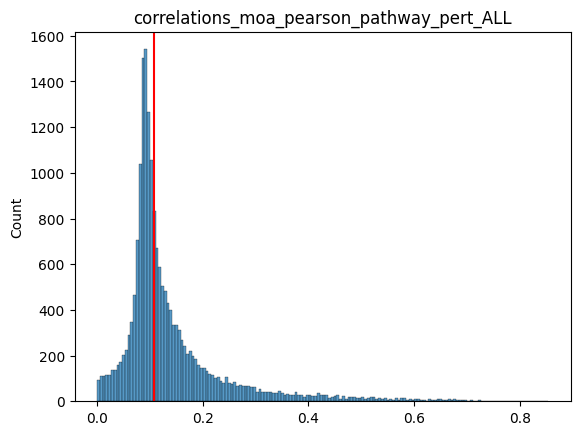

correlations_moa_spearman_pathway_pert_ALL.csv


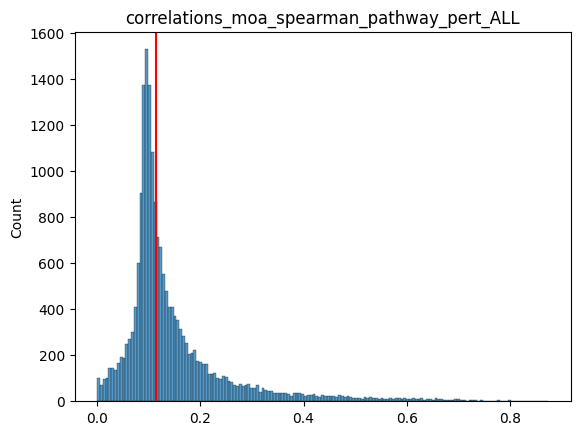

correlations_smiles_spearman_pathway_pert_ALL.csv


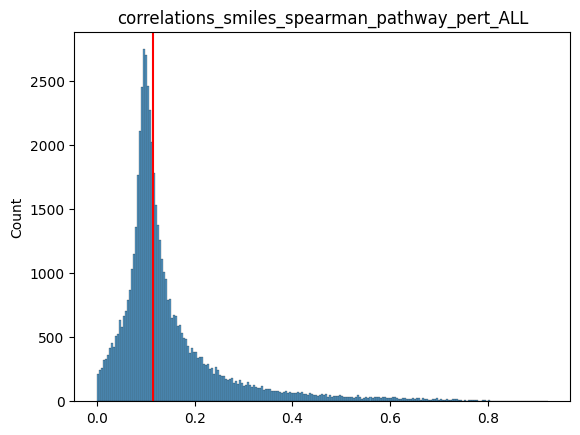

correlations_smiles_pearson_pathway_pert_ALL.csv


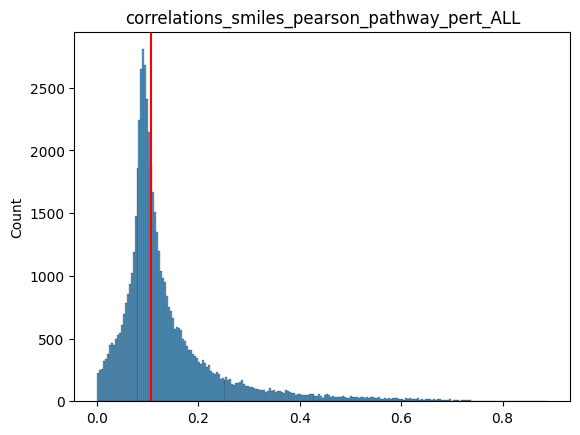

correlations_moa_pearson_raw_pert_ALL.csv


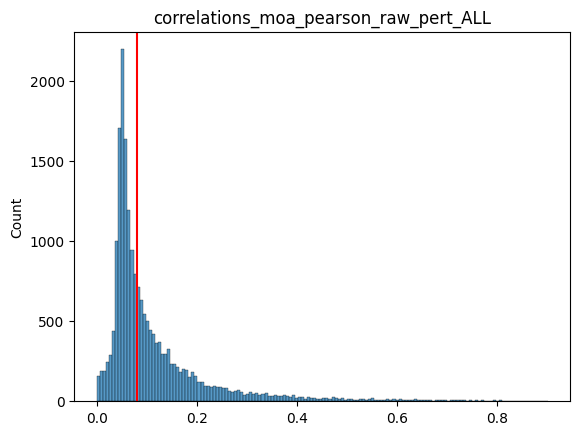

correlations_smiles_pearson_raw_pert_ALL.csv


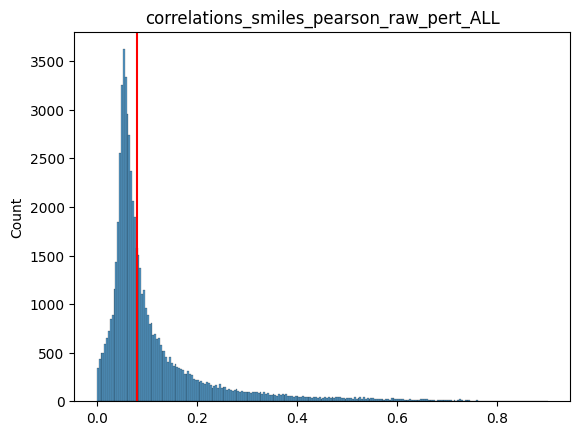

correlations_moa_spearman_raw_pert_ALL.csv


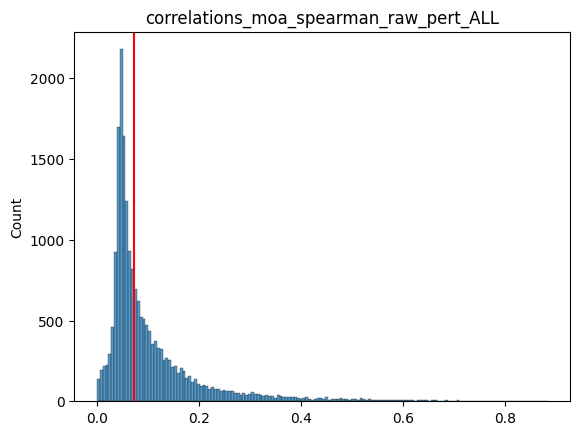

correlations_smiles_spearman_raw_pert_ALL.csv


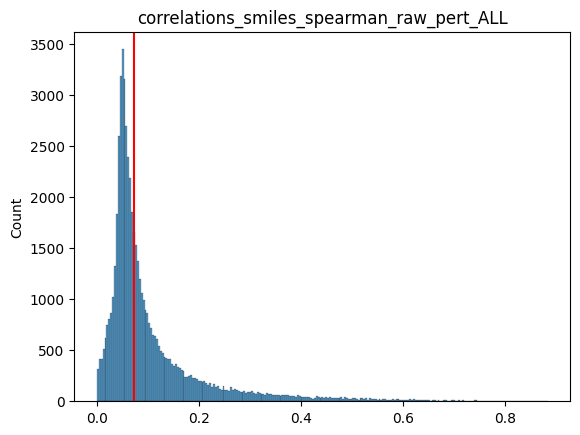

In [ ]:
# Check correlations pattern
OUTPUT = Path('/home/gdelrot/pathway_perturb/outputs/out_exploration_2')
for file in OUTPUT.glob('*pert_ALL*'):
    print(file.name)
    data = pd.read_csv(file)
    data = data.set_index('cell_line',drop=True)
    inter_moa = data['__inter_moa__'].mean()
    cor_values = data.values.flatten()
    
    # Plot
    sns.histplot(cor_values)
    plt.title(str(file.stem))
    plt.axvline(x=inter_moa,color = 'red')
    plt.show()

In [3]:
import re
def parse_setup(filename: str) -> dict:
    """
    Extract (outname, cor_type, pert_type) from filename.
    e.g. correlations_moa_pearson_raw_pert_ALL.csv
    """
    pattern = r'correlations_(\w+)_(pearson|spearman)_(raw_pert|pathway_pert)_ALL'
    m = re.search(pattern, filename)
    if not m:
        return None
    return {
        'outname':   m.group(1),   # moa or smiles
        'cor_type':  m.group(2),   # pearson or spearman
        'pert_type': m.group(3),   # raw_pert or pathway_pert
    }


records = []   # flat list of dicts, one per (setup x cell_line x moa)

for file in sorted(OUTPUT.glob('*pert_ALL*.csv')):
    setup = parse_setup(file.name)
    if setup is None:
        print(f"Could not parse: {file.name}")
        continue

    df = pd.read_csv(file, index_col='cell_line')

    # separate null column from MoA columns
    inter = df['__inter_moa__']
    moa_cols = [c for c in df.columns if c != '__inter_moa__']

    # compute delta matrix: intra - inter (broadcast per cell line)
    delta = df[moa_cols].subtract(inter, axis=0)

    # summary stats per setup per cell line
    for cl in delta.index:
        row = delta.loc[cl].dropna()
        if len(row) == 0:
            continue
        records.append({
            **setup,
            'cell_line':          cl,
            'inter_moa':          inter.loc[cl],
            'mean_delta':         row.mean(),
            'median_delta':       row.median(),
            'frac_above_null':    (row > 0).mean(),
            'n_moas':             len(row),
        })

summary = pd.DataFrame(records)
print(summary.groupby(['outname','cor_type','pert_type'])[
    ['median_delta','frac_above_null','inter_moa']
].median().round(4))

                               median_delta  frac_above_null  inter_moa
outname cor_type pert_type                                             
moa     pearson  pathway_pert        0.0156           0.6563     0.1005
                 raw_pert            0.0179           0.7635     0.0724
        spearman pathway_pert        0.0148           0.6607     0.1079
                 raw_pert            0.0173           0.7609     0.0679
smiles  pearson  pathway_pert        0.0211           0.6503     0.1001
                 raw_pert            0.0294           0.7553     0.0765
        spearman pathway_pert        0.0205           0.6562     0.1086
                 raw_pert            0.0277           0.7586     0.0700


/tmp/ipykernel_795171/3205348765.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_795171/3205348765.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


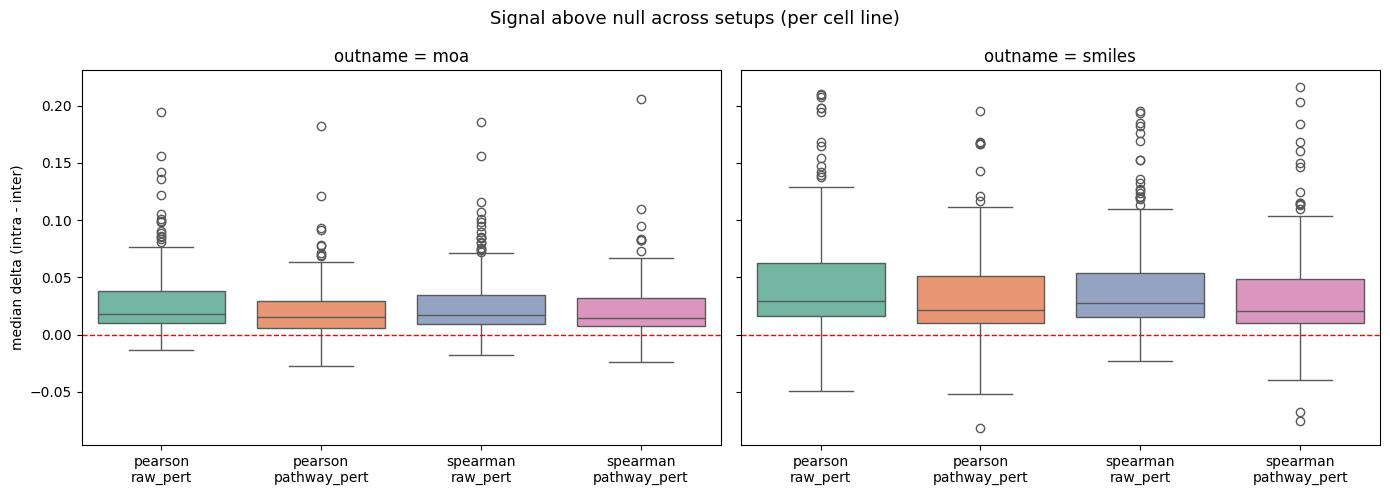

In [28]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, outname in zip(axes, ['moa', 'smiles']):
    sub = summary[summary['outname'] == outname].copy()
    # create a readable label for x axis
    sub['setup'] = sub['cor_type'] + '\n' + sub['pert_type']

    sns.boxplot(
        data=sub,
        x='setup', y='median_delta',
        order=[
            'pearson\nraw_pert', 'pearson\npathway_pert',
            'spearman\nraw_pert','spearman\npathway_pert',
        ],
        palette='Set2', ax=ax
    )
    ax.axhline(0, color='red', linestyle='--', linewidth=1, label='null (delta=0)')
    ax.set_title(f'outname = {outname}')
    ax.set_xlabel('')
    ax.set_ylabel('median delta (intra - inter)')

plt.suptitle('Signal above null across setups (per cell line)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT / 'compare_setups_delta_boxplot.png', dpi=150)
plt.show()
#plt.close()


/tmp/ipykernel_795171/2331338741.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_795171/2331338741.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


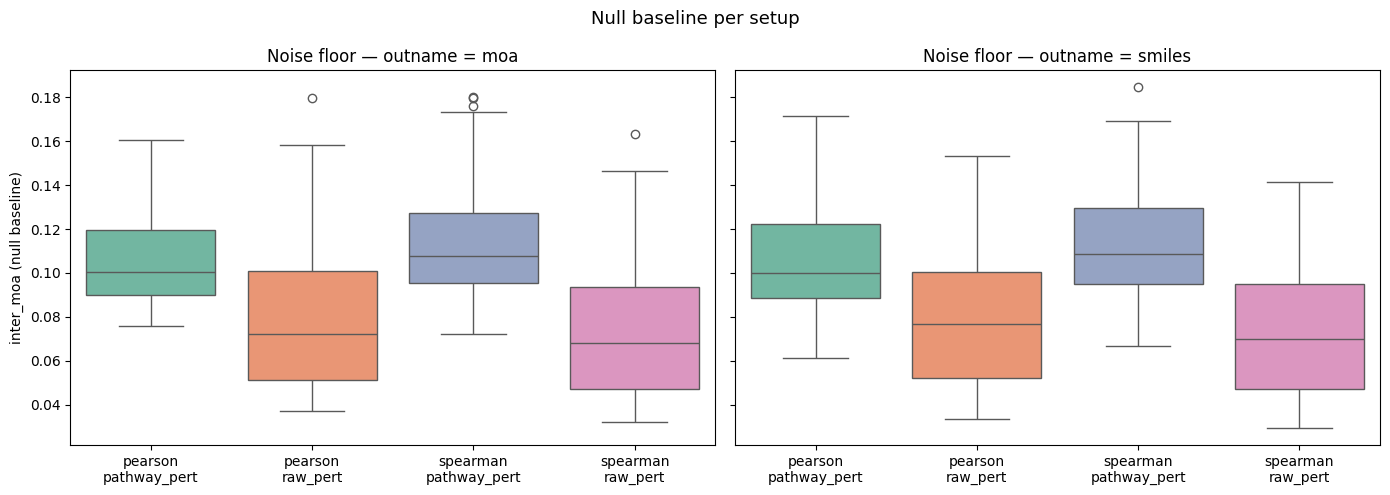

In [30]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, outname in zip(axes, ['moa', 'smiles']):
    sub = summary[summary['outname'] == outname].copy()
    sub['setup'] = sub['cor_type'] + '\n' + sub['pert_type']

    sns.boxplot(
        data=sub,
        x='setup', y='inter_moa',
        palette='Set2', ax=ax
    )
    ax.set_title(f'Noise floor — outname = {outname}')
    ax.set_xlabel('')
    ax.set_ylabel('inter_moa (null baseline)')

plt.suptitle('Null baseline per setup', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT / 'compare_setups_null_baseline.png', dpi=150)
plt.show()

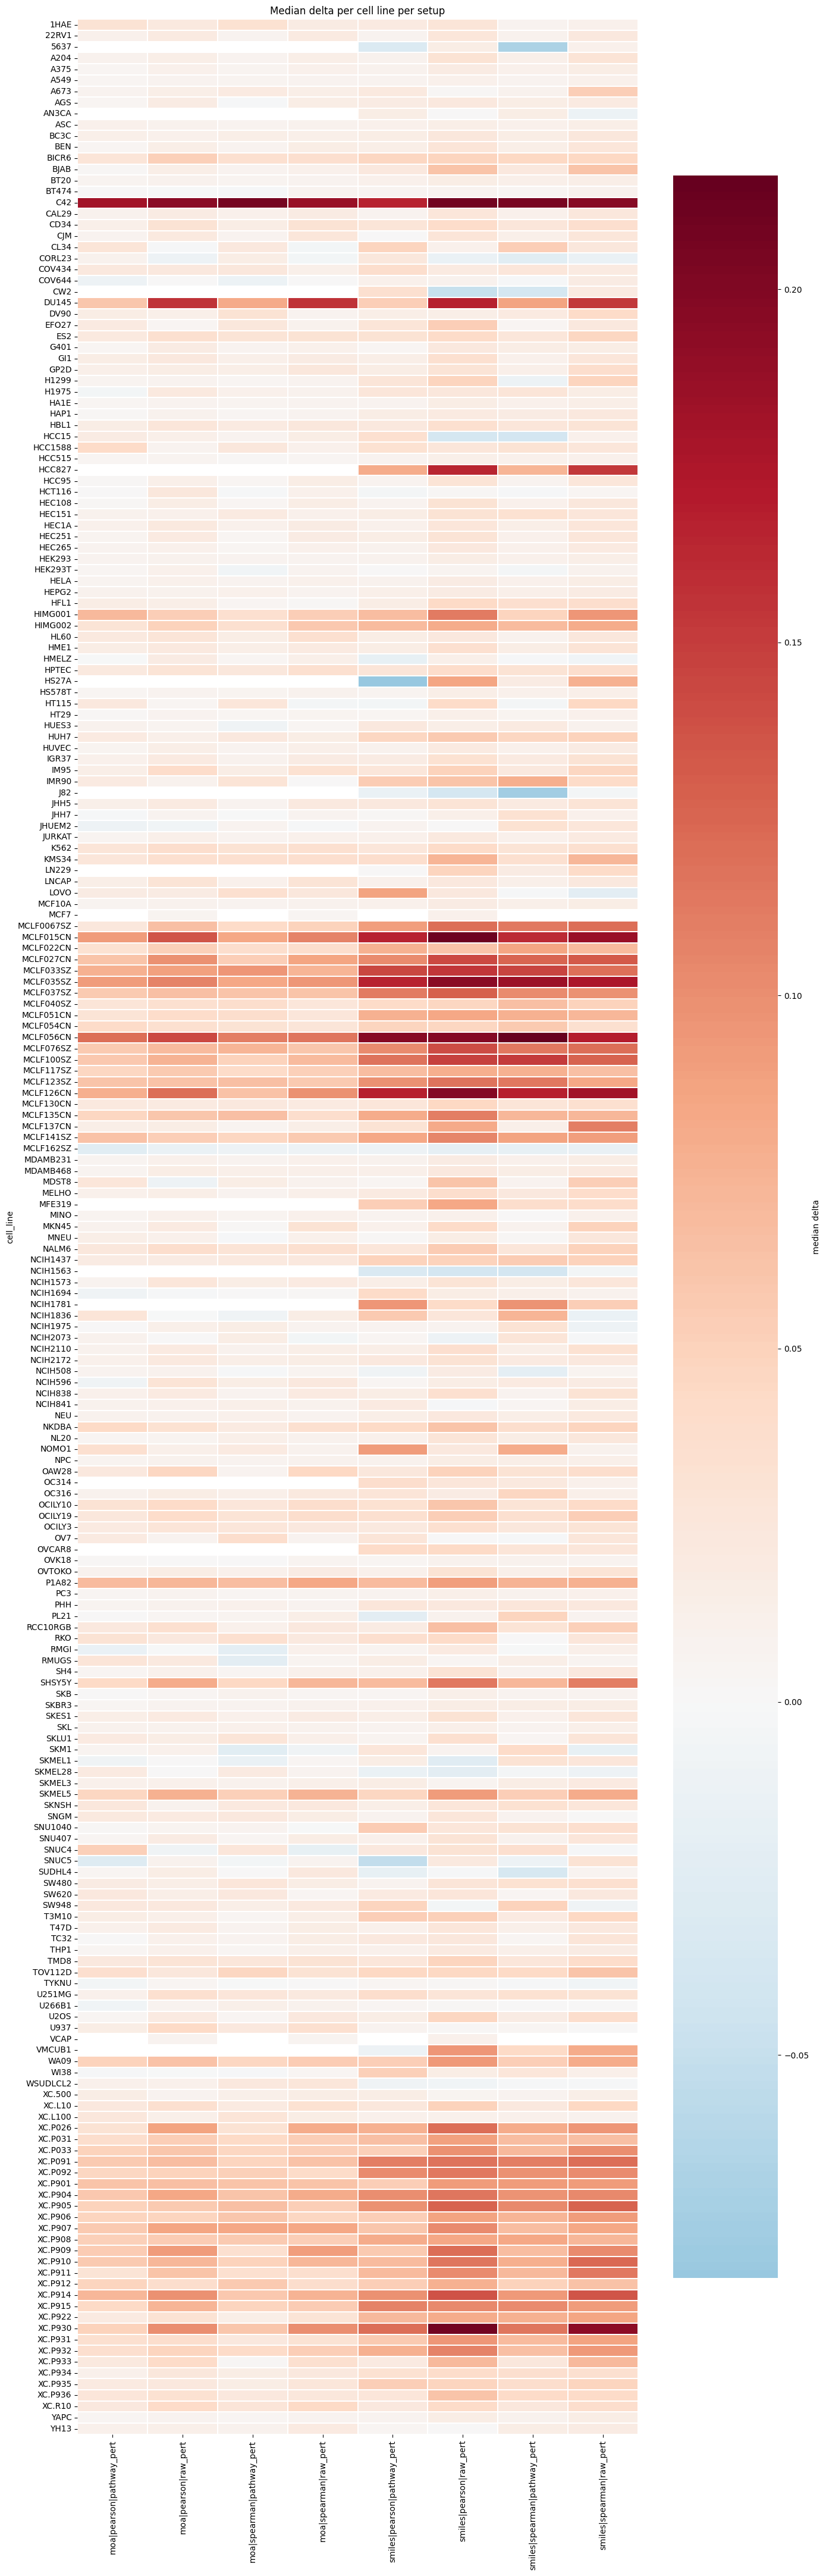

In [32]:

pivot = summary.pivot_table(
    index='cell_line',
    columns=['outname','cor_type','pert_type'],
    values='median_delta'
)
pivot.columns = ['|'.join(c) for c in pivot.columns]   # flatten MultiIndex

plt.figure(figsize=(14, max(6, len(pivot) * 0.2)))
sns.heatmap(
    pivot,
    cmap='RdBu_r', center=0,
    linewidths=0.3,
    yticklabels=True,
    cbar_kws={'label': 'median delta'}
)
plt.title('Median delta per cell line per setup')
plt.tight_layout()
plt.savefig(OUTPUT / 'compare_setups_heatmap.png', dpi=150)
plt.show()

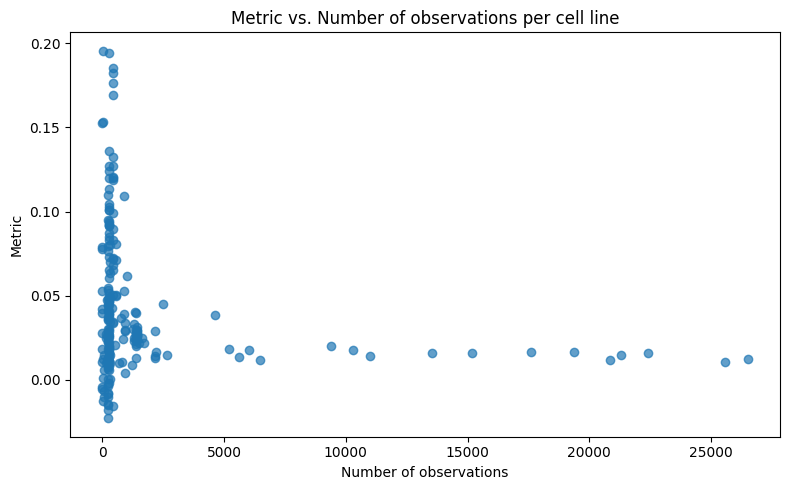

In [12]:
import numpy as np
import matplotlib.pyplot as plt

l1000_annot = annotate_drug_info(loader.l1000_pathway_data, loader, 'moa')
pair_annotated = annotate_cell_info(l1000_annot, loader, None)

# Count observations per cell line
obs_per_cell_line = pair_annotated.groupby('cell_iname')['cell_iname'].count()


# Load correlation data
cor_smiles_raw = pd.read_csv(
    '/home/gdelrot/pathway_perturb/outputs/out_exploration_2/correlations_smiles_spearman_raw_pert_ALL.csv',
    index_col=0
)

# Extract and remove the inter_moa column
cor_inter = cor_smiles_raw['__inter_moa__']
cor_smiles_raw = cor_smiles_raw.drop(labels='__inter_moa__', axis=1)

# Compute metric per cell line
cell_line_metrics = {}
for cell_line, values in cor_smiles_raw.iterrows():
    cell_line_metrics[cell_line] = values.median() - cor_inter.loc[cell_line]

# Build a joined DataFrame (index = cell_line)
cell_line_df = pd.DataFrame({
    'metric': pd.Series(cell_line_metrics),
    'n_obs': obs_per_cell_line
}).dropna()

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(cell_line_df['n_obs'], cell_line_df['metric'], alpha=0.7)

ax.set_xlabel('Number of observations')
ax.set_ylabel('Metric')
ax.set_title('Metric vs. Number of observations per cell line')
plt.tight_layout()
plt.show()

count     227.000000
mean      418.741162
std      1334.178908
min         0.000000
25%         6.414966
50%        24.170213
75%       114.283688
max      9893.606285
Name: n_pairs, dtype: float64
ModeResult(mode=np.float64(28.0), count=np.int64(10))


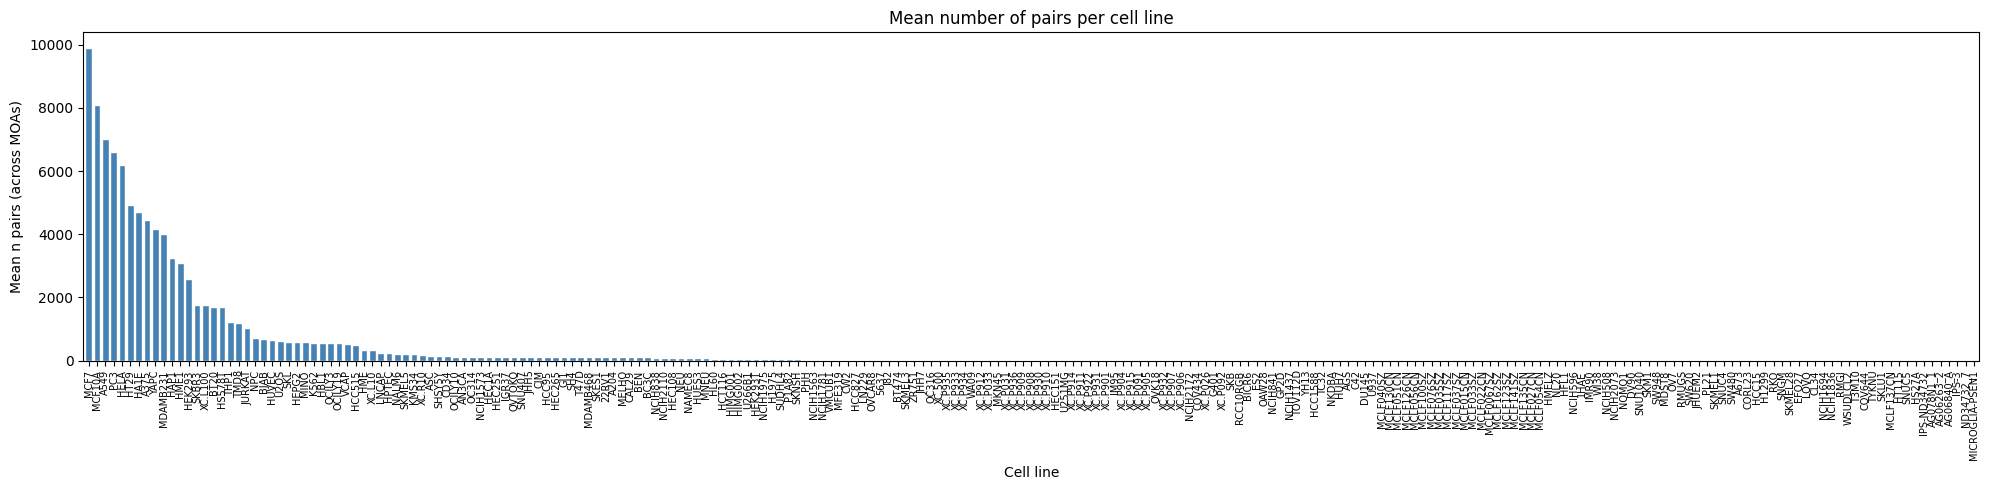

In [15]:
# CHeck the mean number oif generated pairs
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

# ── Annotate ──────────────────────────────────────────────────────────────────
l1000_annot   = annotate_drug_info(loader.l1000_pathway_data, loader, 'moa')
pair_annotated = annotate_cell_info(l1000_annot, loader, None)

# ── Count pairs per (cell_line, MOA) ─────────────────────────────────────────
# n_pert is the group size; pairs = n*(n-1)//2
pair_counts = (
    pair_annotated
    .groupby(['cell_iname', 'moa'])
    .size()                                   # n perturbations per group
    .rename('n_pert')
    .reset_index()
)
pair_counts['n_pairs'] = pair_counts['n_pert'] * (pair_counts['n_pert'] - 1) // 2

# ── Mean pairs per cell line ──────────────────────────────────────────────────
mean_pairs_per_cl = (
    pair_counts
    .groupby('cell_iname')['n_pairs']
    .mean()                                   # mean across MOAs within a cell line
    .sort_values(ascending=False)
)

print(mean_pairs_per_cl.describe())
print(scipy.stats.mode(mean_pairs_per_cl.values.flatten()))

# ── Plot distribution ─────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(20, 5))

mean_pairs_per_cl.sort_values(ascending=False).plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='white', width=0.8
)

ax.set_xlabel('Cell line')
ax.set_ylabel('Mean n pairs (across MOAs)')
ax.set_title('Mean number of pairs per cell line')
ax.tick_params(axis='x', labelsize=7, rotation=90)

plt.tight_layout()
plt.savefig('pair_distribution_per_cl.png', dpi=150)
plt.show()

correlations_moa_pearson_pathway_pert_ALL.csv


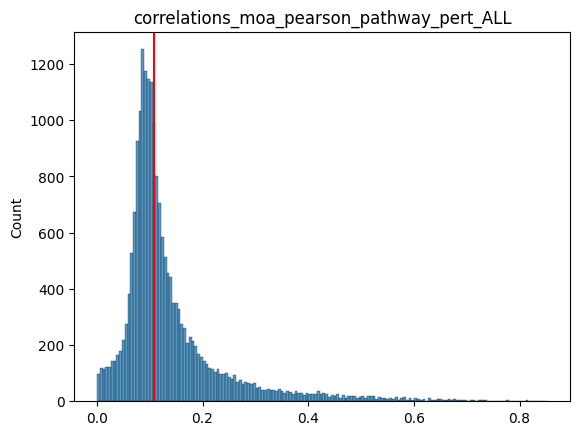

correlations_moa_spearman_pathway_pert_ALL.csv


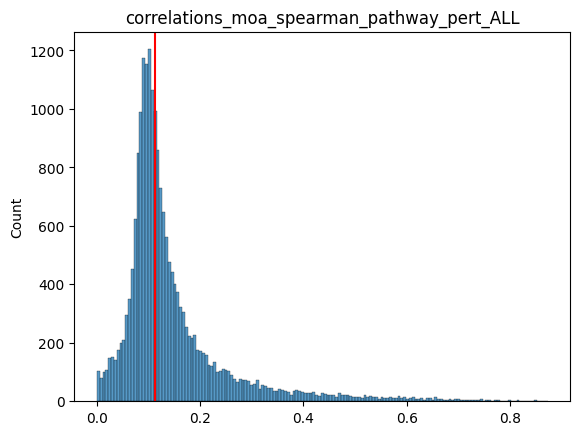

correlations_smiles_spearman_pathway_pert_ALL.csv


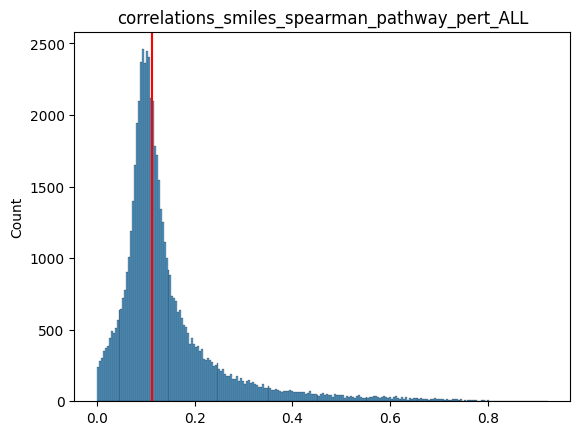

correlations_smiles_pearson_pathway_pert_ALL.csv


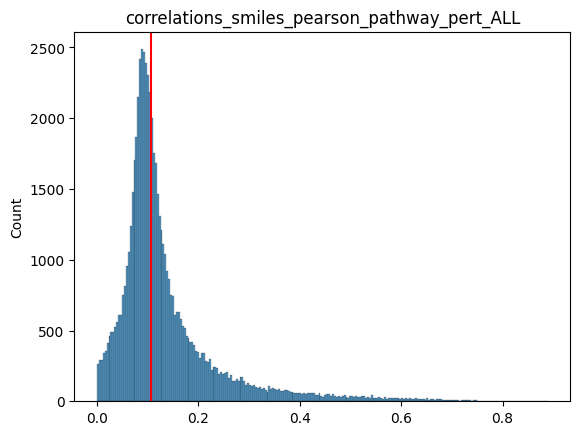

correlations_moa_pearson_raw_pert_ALL.csv


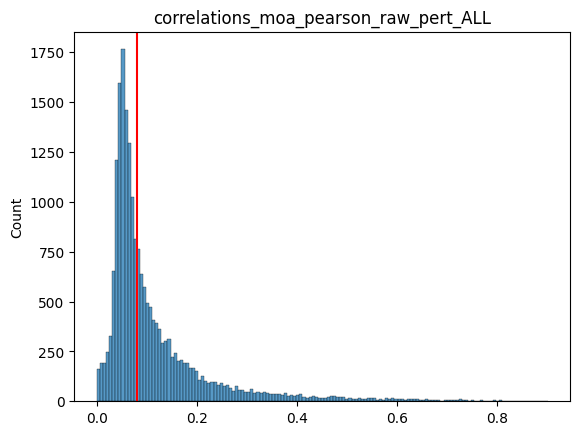

correlations_smiles_pearson_raw_pert_ALL.csv


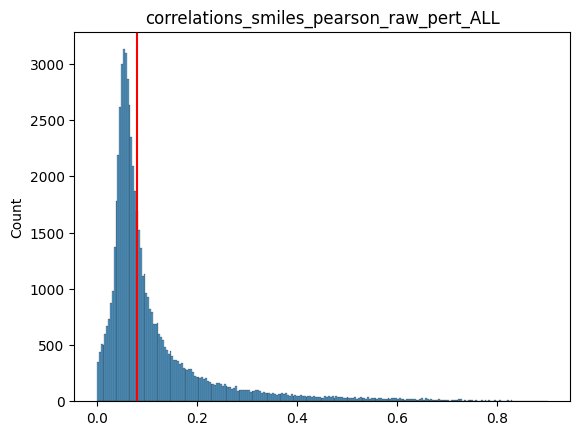

correlations_moa_spearman_raw_pert_ALL.csv


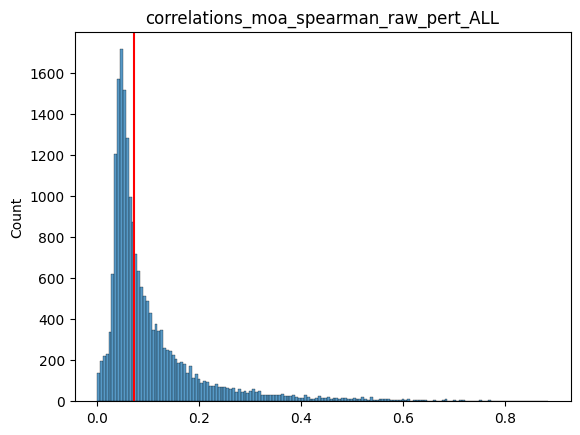

correlations_smiles_spearman_raw_pert_ALL.csv


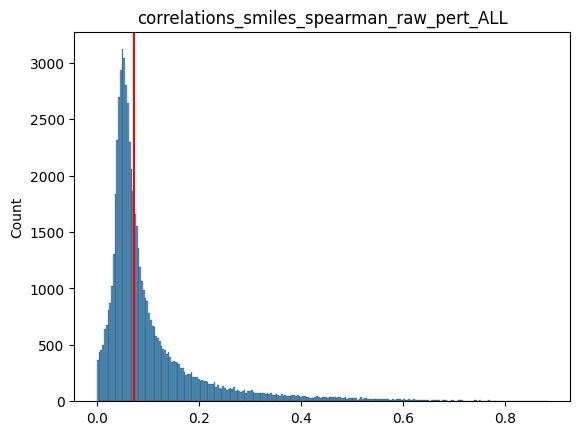

In [5]:
# Check correlations pattern
OUTPUT = Path('/home/gdelrot/pathway_perturb/outputs/corr_cl_subsample')
for file in OUTPUT.glob('*pert_ALL*'):
    print(file.name)
    data = pd.read_csv(file)
    data = data.set_index('cell_line',drop=True)
    inter_moa = data['__inter_moa__'].mean()
    cor_values = data.values.flatten()
    
    # Plot
    sns.histplot(cor_values)
    plt.title(str(file.stem))
    plt.axvline(x=inter_moa,color = 'red')
    plt.show()

In [6]:
import re
def parse_setup(filename: str) -> dict:
    """
    Extract (outname, cor_type, pert_type) from filename.
    e.g. correlations_moa_pearson_raw_pert_ALL.csv
    """
    pattern = r'correlations_(\w+)_(pearson|spearman)_(raw_pert|pathway_pert)_ALL'
    m = re.search(pattern, filename)
    if not m:
        return None
    return {
        'outname':   m.group(1),   # moa or smiles
        'cor_type':  m.group(2),   # pearson or spearman
        'pert_type': m.group(3),   # raw_pert or pathway_pert
    }


records = []   # flat list of dicts, one per (setup x cell_line x moa)

for file in sorted(OUTPUT.glob('*pert_ALL*.csv')):
    setup = parse_setup(file.name)
    if setup is None:
        print(f"Could not parse: {file.name}")
        continue

    df = pd.read_csv(file, index_col='cell_line')

    # separate null column from MoA columns
    inter = df['__inter_moa__']
    moa_cols = [c for c in df.columns if c != '__inter_moa__']

    # compute delta matrix: intra - inter (broadcast per cell line)
    delta = df[moa_cols].subtract(inter, axis=0)

    # summary stats per setup per cell line
    for cl in delta.index:
        row = delta.loc[cl].dropna()
        if len(row) == 0:
            continue
        records.append({
            **setup,
            'cell_line':          cl,
            'inter_moa':          inter.loc[cl],
            'mean_delta':         row.mean(),
            'median_delta':       row.median(),
            'frac_above_null':    (row > 0).mean(),
            'n_moas':             len(row),
        })

summary = pd.DataFrame(records)
print(summary.groupby(['outname','cor_type','pert_type'])[
    ['median_delta','frac_above_null','inter_moa']
].median().round(4))

                               median_delta  frac_above_null  inter_moa
outname cor_type pert_type                                             
moa     pearson  pathway_pert        0.0153           0.6481     0.1022
                 raw_pert            0.0185           0.7421     0.0759
        spearman pathway_pert        0.0148           0.6531     0.1058
                 raw_pert            0.0178           0.7533     0.0681
smiles  pearson  pathway_pert        0.0218           0.6449     0.1003
                 raw_pert            0.0299           0.7511     0.0763
        spearman pathway_pert        0.0247           0.6486     0.1065
                 raw_pert            0.0286           0.7447     0.0671


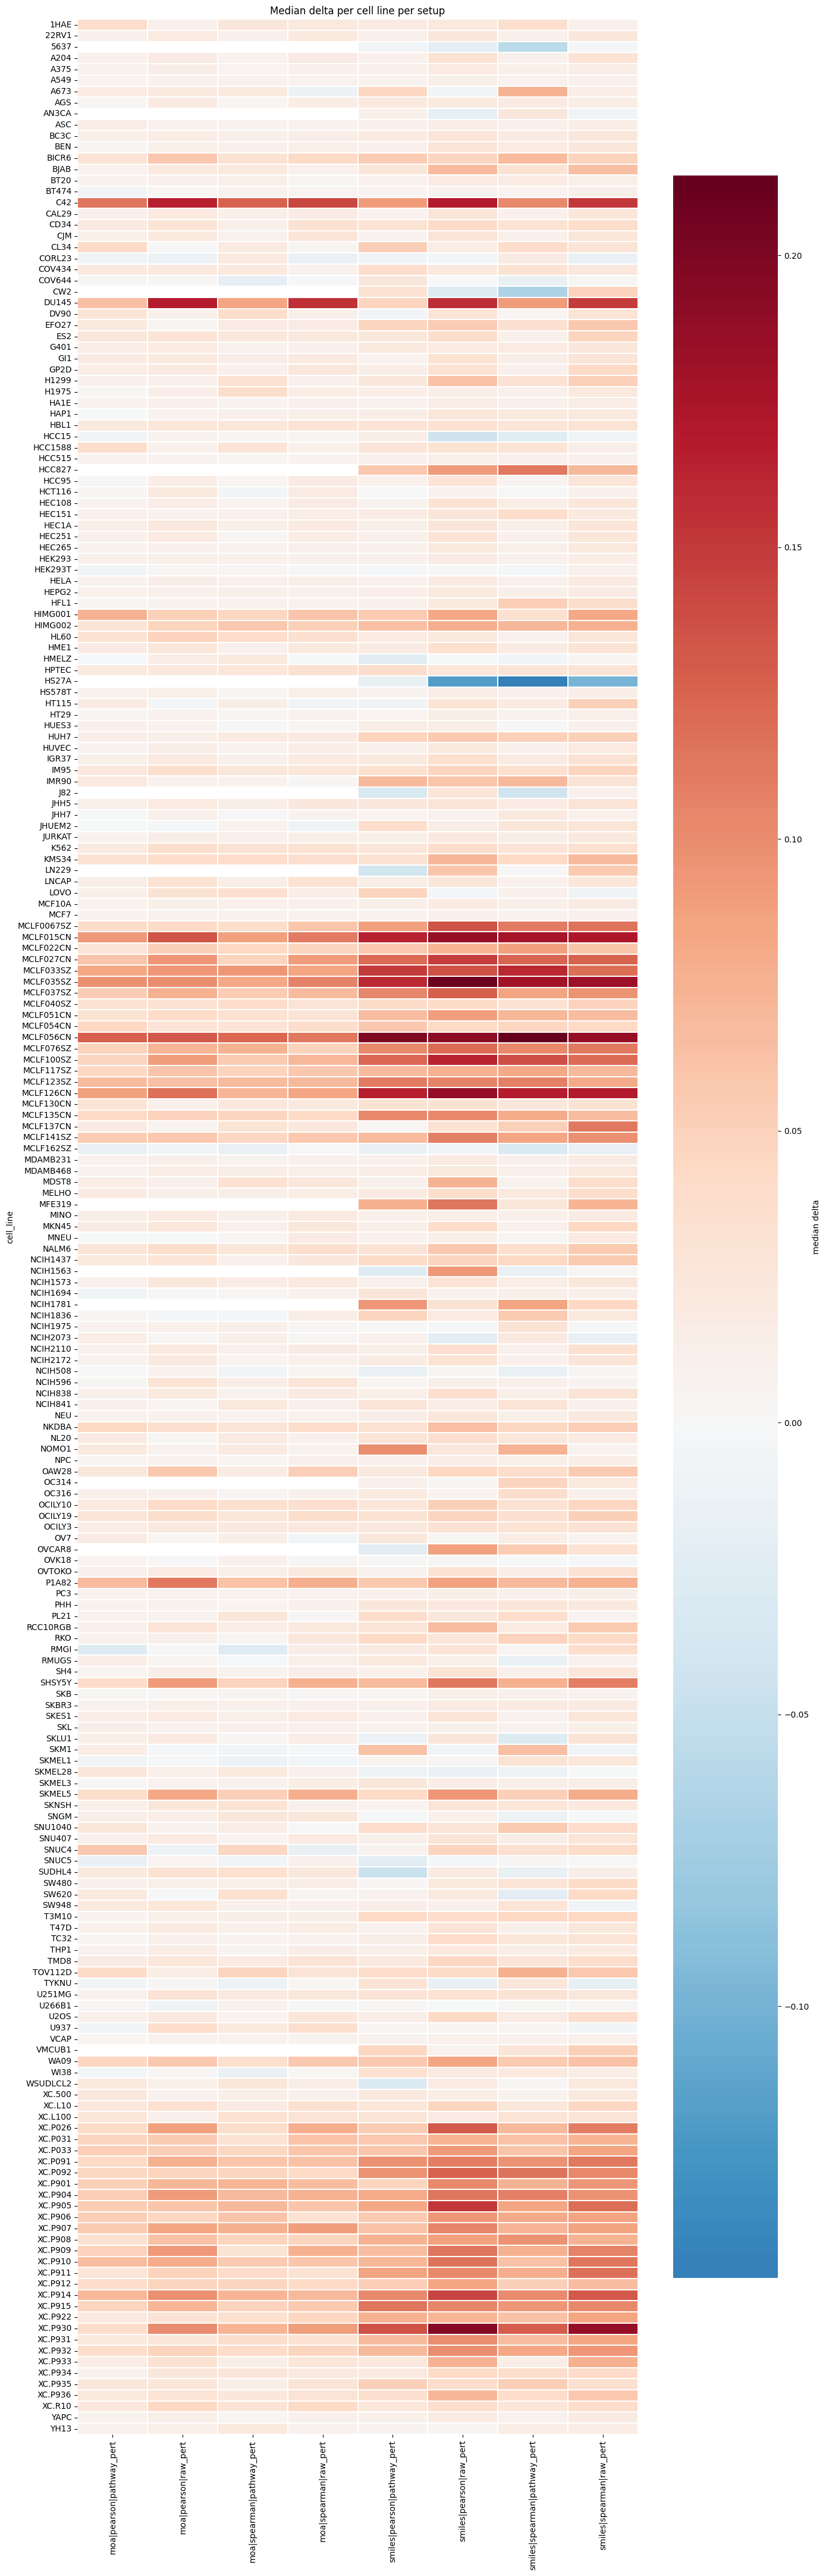

In [7]:

pivot = summary.pivot_table(
    index='cell_line',
    columns=['outname','cor_type','pert_type'],
    values='median_delta'
)
pivot.columns = ['|'.join(c) for c in pivot.columns]   # flatten MultiIndex

plt.figure(figsize=(14, max(6, len(pivot) * 0.2)))
sns.heatmap(
    pivot,
    cmap='RdBu_r', center=0,
    linewidths=0.3,
    yticklabels=True,
    cbar_kws={'label': 'median delta'}
)
plt.title('Median delta per cell line per setup')
plt.tight_layout()
plt.savefig(OUTPUT / 'compare_setups_heatmap.png', dpi=150)
plt.show()

In [3]:
# Compounds groups
compound_info = loader.compound_info.copy()

# 
grouped = compound_info.groupby(['moa','cluster_id']).groups

for (moa, cluster_id), index in grouped.items():
    print(f"MOA: {moa}, Cluster ID: {cluster_id}, N compounds: {len(index)}")
    


MOA: 11-beta hydroxysteroid dehydrogenase inhibitor, Cluster ID: 266.0, N compounds: 88
MOA: 11-beta-HSD1 inhibitor, Cluster ID: 240.0, N compounds: 8
MOA: 11-beta-HSD1 inhibitor, Cluster ID: 251.0, N compounds: 1
MOA: 11-beta-HSD1 inhibitor, Cluster ID: 268.0, N compounds: 4
MOA: 11-beta-HSD1 inhibitor, Cluster ID: 3217.0, N compounds: 1
MOA: 3-ketoacyl CoA thiolase inhibitor, Cluster ID: 1643.0, N compounds: 1
MOA: 3beta-hydroxy-delta5-steroid dehydrogenase inhibitor, Cluster ID: 254.0, N compounds: 9
MOA: 5 alpha reductase inhibitor, Cluster ID: 248.0, N compounds: 16
MOA: 5 alpha reductase inhibitor, Cluster ID: 3440.0, N compounds: 3
MOA: ABC transporter expression enhancer, Cluster ID: 1951.0, N compounds: 8
MOA: ABC transporter expression enhancer, Cluster ID: 3120.0, N compounds: 12
MOA: ACAT inhibitor, Cluster ID: 1788.0, N compounds: 1
MOA: ACAT inhibitor, Cluster ID: 3409.0, N compounds: 4
MOA: ACAT inhibitor, Cluster ID: 3455.0, N compounds: 4
MOA: AGT inhibitor, Cluster ID

In [19]:
compound_info = loader.compound_info
import numpy as np
with open ('/home/gdelrot/pathway_perturb/data/moa.txt','w') as file:
    for moa in compound_info['moa'].dropna().unique():
        if moa != 'nan':
            file.write(f'{moa}\n')

moa
Serotonin receptor antagonist                                               91
Adrenergic receptor antagonist                                              81
Glucocorticoid receptor agonist                                             81
Cyclooxygenase inhibitor                                                    80
Dopamine receptor antagonist                                                72
Acetylcholine receptor antagonist                                           68
Histamine receptor antagonist                                               66
Adrenergic receptor agonist                                                 60
Glutamate receptor antagonist                                               50
Phosphodiesterase inhibitor                                                 48
Serotonin receptor agonist                                                  46
Calcium channel blocker                                                     45
Topoisomerase inhibitor                         

<Axes: >

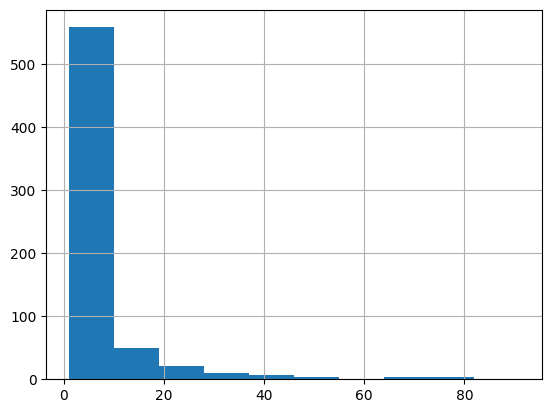

In [9]:
pd.set_option('display.max_rows',None)
compound_info = loader.compound_info
compound_info = compound_info.groupby('moa')['canonical_smiles'].nunique()
print(compound_info.sort_values(ascending=False))
compound_info.hist()